# VeriTriage — Chip Family Analysis
## Architectural Comparison: RISCY vs zero-riscy

**Key Question:** Do high-performance chips (RISCY) fail 
sign-off checks differently than low-power chips (zero-riscy)?

**This is the novel contribution** — showing that chip architecture
affects verification failure patterns, and triage models must be
architecture-aware.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from pathlib import Path

ROOT = Path(r"C:\Users\TUSHAR\2026-27\PROJECTS\VeriTriage")
df = pd.read_csv(ROOT / "data/processed/veritriage_features.csv")

FEATURE_COLS = [c for c in df.columns if c.startswith('cd_') or c.startswith('mr_')]
LABEL_COLS   = ['label_ir', 'label_drc', 'label_cg']

riscy = df[df['chip_family'] == 'RISCY']
zero  = df[df['chip_family'] == 'zero-riscy']

print(f"RISCY samples:      {len(riscy)}")
print(f"zero-riscy samples: {len(zero)}")

RISCY samples:      7078
zero-riscy samples: 3164


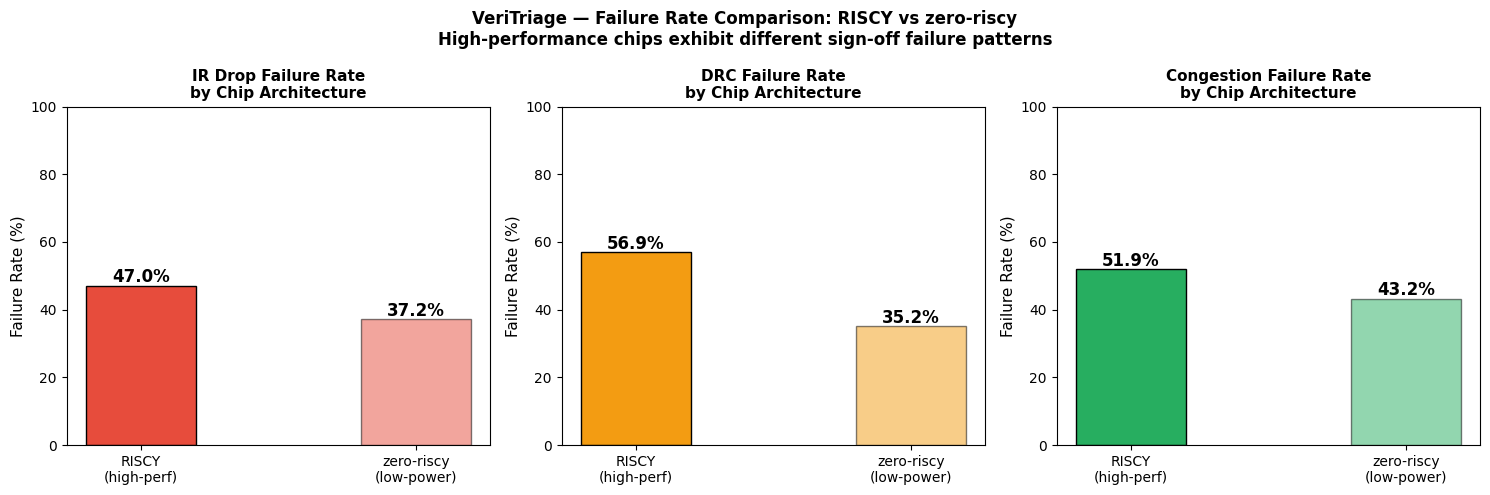


Failure rate comparison:
Task         |    RISCY | zero-riscy | Difference
------------------------------------------------
IR Drop      |    47.0% |      37.2% |       9.8%
DRC          |    56.9% |      35.2% |      21.7%
Congestion   |    51.9% |      43.2% |       8.7%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tasks      = ['IR Drop', 'DRC', 'Congestion']
label_cols = ['label_ir', 'label_drc', 'label_cg']
colors     = ['#e74c3c', '#f39c12', '#27ae60']

for idx, (task, col, color) in enumerate(zip(tasks, label_cols, colors)):
    riscy_fail = riscy[col].mean() * 100
    zero_fail  = zero[col].mean()  * 100

    x = [0, 1]
    heights = [riscy_fail, zero_fail]
    bar_colors = [color, color]
    alphas = [1.0, 0.5]

    for xi, h, c, a in zip(x, heights, bar_colors, alphas):
        axes[idx].bar(xi, h, color=c, alpha=a, edgecolor='black', width=0.4)

    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['RISCY\n(high-perf)', 'zero-riscy\n(low-power)'])
    axes[idx].set_ylim(0, 100)
    axes[idx].set_ylabel('Failure Rate (%)', fontsize=11)
    axes[idx].set_title(f'{task} Failure Rate\nby Chip Architecture',
                        fontsize=11, fontweight='bold')

    for xi, val in zip(x, heights):
        axes[idx].text(xi, val + 1, f'{val:.1f}%', ha='center',
                       fontweight='bold', fontsize=12)

plt.suptitle('VeriTriage — Failure Rate Comparison: RISCY vs zero-riscy\n'
             'High-performance chips exhibit different sign-off failure patterns',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / "results/plots/04_chip_family_failure_rates.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("\nFailure rate comparison:")
print(f"{'Task':12s} | {'RISCY':>8s} | {'zero-riscy':>10s} | {'Difference':>10s}")
print("-"*48)
for task, col in zip(tasks, label_cols):
    r = riscy[col].mean() * 100
    z = zero[col].mean()  * 100
    diff = abs(r - z)
    print(f"{task:12s} | {r:7.1f}% | {z:9.1f}% | {diff:9.1f}%")

In [7]:
# Cross-family generalization test
# Train on RISCY → test on zero-riscy and vice versa
# This proves architecture-aware triage is necessary

print("="*55)
print("  Cross-Architecture Generalization Test")
print("="*55)

cross_results = []

for label in LABEL_COLS:
    # Scenario 1: Train on RISCY, test on zero-riscy
    X_r = riscy[FEATURE_COLS].values
    y_r = riscy[label].values
    X_z = zero[FEATURE_COLS].values
    y_z = zero[label].values

    # Train on RISCY
    clf_r = xgb.XGBClassifier(n_estimators=300, max_depth=6,
                                learning_rate=0.05, random_state=42,
                                verbosity=0, eval_metric='logloss')
    clf_r.fit(X_r, y_r)
    acc_r_to_z = accuracy_score(y_z, clf_r.predict(X_z))
    auc_r_to_z = roc_auc_score(y_z, clf_r.predict_proba(X_z)[:,1])

    # Train on zero-riscy
    clf_z = xgb.XGBClassifier(n_estimators=300, max_depth=6,
                                learning_rate=0.05, random_state=42,
                                verbosity=0, eval_metric='logloss')
    clf_z.fit(X_z, y_z)
    acc_z_to_r = accuracy_score(y_r, clf_z.predict(X_r))
    auc_z_to_r = roc_auc_score(y_r, clf_z.predict_proba(X_r)[:,1])

    # Train on mixed (baseline)
    X_all = df[FEATURE_COLS].values
    y_all = df[label].values
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all,
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=y_all)
    clf_mix = xgb.XGBClassifier(n_estimators=300, max_depth=6,
                                  learning_rate=0.05, random_state=42,
                                  verbosity=0, eval_metric='logloss')
    clf_mix.fit(X_tr, y_tr)
    acc_mix = accuracy_score(y_te, clf_mix.predict(X_te))
    auc_mix = roc_auc_score(y_te, clf_mix.predict_proba(X_te)[:,1])

    cross_results.append({
        'Task':              label.replace('label_','').upper(),
        'RISCY→zero (ACC)':  round(acc_r_to_z, 4),
        'RISCY→zero (AUC)':  round(auc_r_to_z, 4),
        'zero→RISCY (ACC)':  round(acc_z_to_r, 4),
        'zero→RISCY (AUC)':  round(auc_z_to_r, 4),
        'Mixed (ACC)':       round(acc_mix, 4),
        'Mixed (AUC)':       round(auc_mix, 4),
    })

    print(f"\n  {label.upper()}")
    print(f"    RISCY → zero-riscy:  ACC={acc_r_to_z:.4f}  AUC={auc_r_to_z:.4f}")
    print(f"    zero  → RISCY:       ACC={acc_z_to_r:.4f}  AUC={auc_z_to_r:.4f}")
    print(f"    Mixed (baseline):    ACC={acc_mix:.4f}  AUC={auc_mix:.4f}")

df_cross = pd.DataFrame(cross_results)
df_cross.to_csv(ROOT / "data/processed/cross_family_results.csv", index=False)
print("\n" + "="*55)
print(df_cross.to_string(index=False))

  Cross-Architecture Generalization Test

  LABEL_IR
    RISCY → zero-riscy:  ACC=0.6296  AUC=0.5725
    zero  → RISCY:       ACC=0.5750  AUC=0.6218
    Mixed (baseline):    ACC=0.8209  AUC=0.9105

  LABEL_DRC
    RISCY → zero-riscy:  ACC=0.7690  AUC=0.8512
    zero  → RISCY:       ACC=0.6916  AUC=0.7951
    Mixed (baseline):    ACC=0.8394  AUC=0.9159

  LABEL_CG
    RISCY → zero-riscy:  ACC=0.8138  AUC=0.9347
    zero  → RISCY:       ACC=0.8398  AUC=0.8873
    Mixed (baseline):    ACC=0.9424  AUC=0.9696

Task  RISCY→zero (ACC)  RISCY→zero (AUC)  zero→RISCY (ACC)  zero→RISCY (AUC)  Mixed (ACC)  Mixed (AUC)
  IR            0.6296            0.5725            0.5750            0.6218       0.8209       0.9105
 DRC            0.7690            0.8512            0.6916            0.7951       0.8394       0.9159
  CG            0.8138            0.9347            0.8398            0.8873       0.9424       0.9696


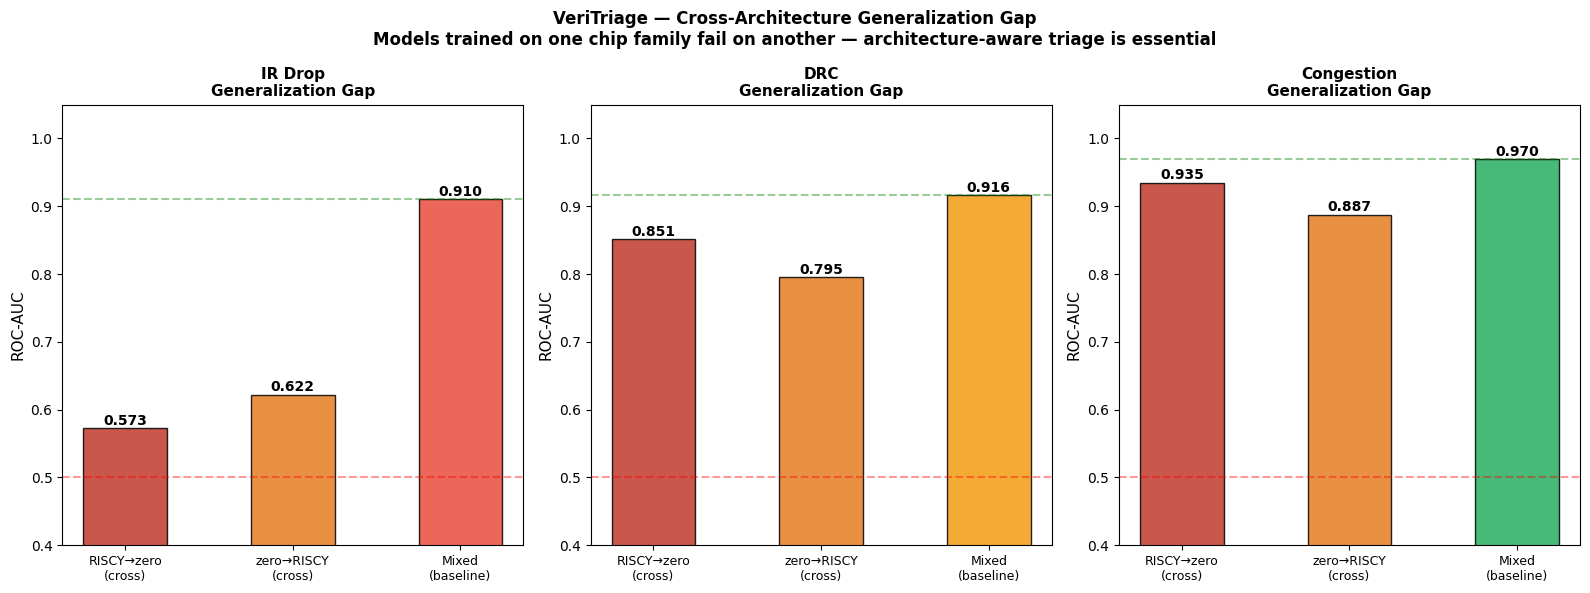

Plot saved!


In [8]:
# Visualize the generalization gap
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

tasks    = ['IR Drop', 'DRC', 'Congestion']
r_to_z   = [0.5725, 0.8512, 0.9347]
z_to_r   = [0.6218, 0.7951, 0.8873]
mixed    = [0.9105, 0.9159, 0.9696]
colors   = ['#e74c3c', '#f39c12', '#27ae60']

for idx, (task, r2z, z2r, mix, color) in enumerate(
        zip(tasks, r_to_z, z_to_r, mixed, colors)):

    bars_x = [0, 1, 2]
    bars_h = [r2z, z2r, mix]
    bar_colors = ['#c0392b', '#e67e22', color]
    labels = ['RISCY→zero\n(cross)', 'zero→RISCY\n(cross)', 'Mixed\n(baseline)']

    for xi, h, c in zip(bars_x, bars_h, bar_colors):
        axes[idx].bar(xi, h, color=c, edgecolor='black',
                      width=0.5, alpha=0.85)
        axes[idx].text(xi, h + 0.005, f'{h:.3f}',
                       ha='center', fontweight='bold', fontsize=10)

    axes[idx].set_xticks(bars_x)
    axes[idx].set_xticklabels(labels, fontsize=9)
    axes[idx].set_ylim(0.4, 1.05)
    axes[idx].set_ylabel('ROC-AUC', fontsize=11)
    axes[idx].set_title(f'{task}\nGeneralization Gap',
                        fontsize=11, fontweight='bold')
    axes[idx].axhline(0.5, color='red', linestyle='--',
                      alpha=0.4, label='Random baseline')
    axes[idx].axhline(mix, color='green', linestyle='--',
                      alpha=0.4, label='Mixed baseline')

plt.suptitle('VeriTriage — Cross-Architecture Generalization Gap\n'
             'Models trained on one chip family fail on another — '
             'architecture-aware triage is essential',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / "results/plots/04_generalization_gap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")